# Simulator Production-Run Analysis

This notebook is a thesis-facing deep dive for the fixed production run `output/2026-06-26_02-48-14`. The data is intentionally pinned so the reported results do not change when newer output folders are created.

The analysis answers one main research question: How accurately does the LLM conflict resolver resolve conflicting diagnoses and action recommendations from monitoring agents compared with the ground-truth, ideal-scenario resolution in a simulated cyber-physical factory?

In [1]:
from pathlib import Path
import sys

from IPython.display import Markdown, display

NOTEBOOK_FILE = globals().get("__vsc_ipynb_file__")
NOTEBOOK_DIR = Path(NOTEBOOK_FILE).resolve().parent if NOTEBOOK_FILE else Path.cwd().resolve()
PROJECT_ROOT = NOTEBOOK_DIR.parent if NOTEBOOK_DIR.name == "analysis" else NOTEBOOK_DIR
if str(PROJECT_ROOT) not in sys.path:
	sys.path.insert(0, str(PROJECT_ROOT))

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

from cps.agents.report_selection import PASSIVE_ACTIONS
from analysis.run_loader import (
	conflict_type_counts,
	decision_failure_taxonomy,
	example_decisions,
	duplicate_ground_truth_diagnosis_audit,
	ground_truth_audit_table,
	load_run,
	parse_simulation_log,
	run_summary,
	save_fig,
	traceability_audit,
)

OUTPUT_ROOT = PROJECT_ROOT / "output"
SELECTED_RUN_PATH = OUTPUT_ROOT / "2026-06-26_02-48-14"
run = load_run(SELECTED_RUN_PATH)
FIGURES_DIR = run.run_dir / "figures"
ANALYSIS_SUMMARY_DIR = OUTPUT_ROOT / "analysis_summary"
ANALYSIS_SUMMARY_DIR.mkdir(parents=True, exist_ok=True)
fault_repairs, throughput = parse_simulation_log(run.run_dir)
summary_row = run_summary(run)


sns.set_theme(context="paper", style="whitegrid", palette="colorblind", font="DejaVu Sans")
plt.rcParams.update({"figure.dpi": 120, "savefig.dpi": 200, "pdf.fonttype": 42, "ps.fonttype": 42})

def display_saved_fig(fig, name: str) -> None:
	save_fig(fig, name, FIGURES_DIR)
	display(fig)
	plt.close(fig)

def format_percentage(value: float) -> str:
	return f"{value:.1%}" if 0 < value < 0.01 else f"{value:.0%}"

def annotate_count_percent_bars(ax, counts, shares, *, orientation: str = "vertical") -> None:
	"""Label a single bar series with both its count and percentage."""
	container = ax.containers[0]
	labels = [f"{int(count)} ({format_percentage(share)})" for count, share in zip(counts, shares)]
	kwargs = {"padding": 3, "fontsize": 8}
	ax.bar_label(container, labels=labels, **kwargs)
	if orientation == "horizontal":
		ax.margins(x=0.22)
	else:
		ax.margins(y=0.20)

def annotate_horizontal_percent_patches(ax, total: int) -> None:
	"""Label horizontal bars split across hue containers."""
	for container in ax.containers:
		labels = []
		for patch in container:
			share = patch.get_width()
			labels.append(f"{round(share * total)} ({format_percentage(share)})" if share > 0 else "")
		ax.bar_label(container, labels=labels, padding=3, fontsize=8)
	ax.margins(x=0.22)

def annotate_grouped_rate_bars(ax, data, *, x: str, hue: str, value: str, denominator: str) -> None:
	"""Label grouped rate bars as numerator/denominator plus percentage."""
	x_order = data[x].drop_duplicates().tolist()
	hue_order = data[hue].drop_duplicates().tolist()
	for container, hue_value in zip(ax.containers, hue_order):
		hue_rows = data[data[hue] == hue_value].set_index(x)
		labels = []
		for x_value in x_order:
			if x_value not in hue_rows.index:
				labels.append("")
				continue
			row = hue_rows.loc[x_value]
			total = int(row[denominator])
			rate = float(row[value])
			labels.append(f"{round(rate * total)}/{total}\n({rate:.0%})")
		ax.bar_label(container, labels=labels, padding=3, fontsize=7)
	ax.set_ylim(0, 1.18)
	ax.set_yticks([0, 0.2, 0.4, 0.6, 0.8, 1.0])

print(f"Loaded run: {run.run_id}")
print(f"Figures directory: {FIGURES_DIR}")


Loaded run: 2026-06-26_02-48-14
Figures directory: /Users/arturmucowski/Projects/thesis/simulator/output/2026-06-26_02-48-14/figures


## Run Summary

The notebook loads the fixed run directory `output/2026-06-26_02-48-14`.


In [2]:
summary = pd.DataFrame([summary_row]).T.reset_index()
summary.columns = ["field", "value"]
display(summary)


,field,value
0,run_id,2026-06-26_02-48-14
1,duration,7385.0
2,completed_products,1000
3,root_faults,77
4,all_faults,130
5,physical_state_issues,18
6,derived_issues,35
7,runtime_reports,20198
8,conflicts,2673
9,resolver_decisions,2673


## 1. Run timeline


These plots place faults, reports, repairs, and throughput on the same simulation-time axis. They are mostly sanity checks for whether the run behaved as expected.


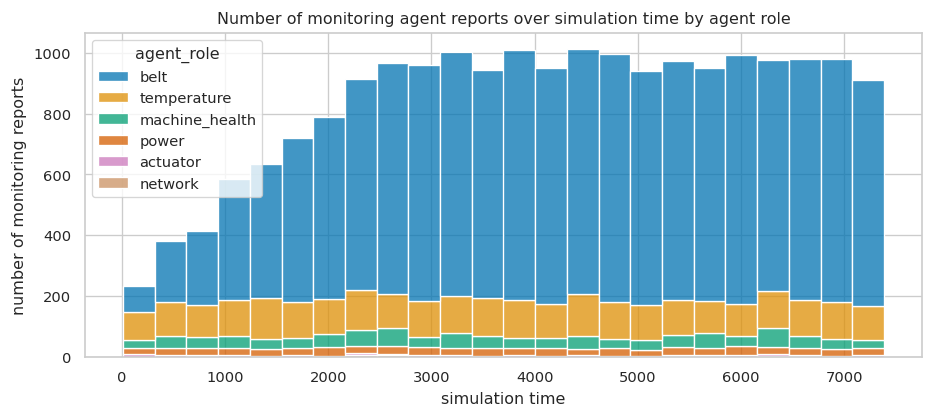

In [3]:
if not run.runtime_reports.empty and {"time", "agent_role"}.issubset(run.runtime_reports.columns):
	fig, ax = plt.subplots(figsize=(9, 3.5))
	sns.histplot(data=run.runtime_reports, x="time", hue="agent_role", bins=24, multiple="stack", ax=ax)
	ax.set_title("Number of monitoring agent reports over simulation time by agent role")
	ax.set_xlabel("simulation time")
	ax.set_ylabel("number of monitoring reports")
	display_saved_fig(fig, "report_volume_by_role")
else:
	print("No runtime report timestamps available.")


The **Number of the monitoring agent reports over simulation time by agent role** chart shows when monitoring agents reported problems during the fixed run. The run produced **20,198 monitoring reports**. Most came from the **belt agent** (**15,751 reports**), followed by **temperature** (**2,821**), **machine health** (**940**), and **power** (**578**). The actuator and network agents were much quieter, with **91** and **17** reports.

The visible result is that the evidence stream is heavily dominated by belt-related monitoring. Report volume is spread across the simulation rather than appearing only at the beginning or end, with the busiest time window containing roughly **1,000 reports**. This means the resolver was not working from a balanced set of agent voices: it mostly received belt evidence, plus smaller but still important temperature, machine-health, and power streams.

**Why are there so many reports for so few faults?** The 20,198 reports are not 20,198 separate problems. Each monitoring agent polls on a recurring cycle and re-emits a report for any condition it still observes, so a single unresolved fault produces one report per cycle for its entire lifetime (the busiest condition was re-reported about every 4 time units). Collapsed by the condition they describe, the 20,198 reports map to only **129 distinct `diagnosis_id` values** out of **130 ground-truth rows** — one reported condition is not re-emitted in the runtime report stream — and the busiest single condition (a persistent belt queue-pressure condition) accounts for **1,630** of them on its own. Most of the volume is downstream symptoms rather than root faults: **82%** of reports (16,587) describe **derived issues** such as persistent queue pressure and transfer-rate degradation, **16%** (3,312) describe physical-state conditions, and only **1.5%** (299) are direct root-fault reports. This is why belt monitoring dominates — belt faults spawn persistent, continuously re-observed downstream effects across many segments — and why the report count is large even though only 77 root faults were injected.


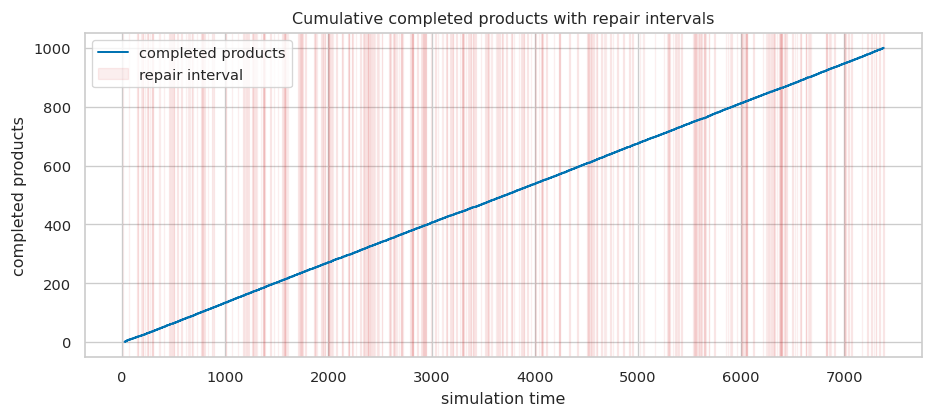

In [4]:
if throughput.empty:
	print("No throughput timestamps available.")
else:
	fig, ax = plt.subplots(figsize=(9, 3.5))
	ax.step(throughput["time"], throughput["sequence"], where="post", label="completed products")
	repair_label = "repair interval"
	for row in fault_repairs.itertuples():
		if pd.notna(row.start_t) and pd.notna(row.end_t):
			ax.axvspan(row.start_t, row.end_t, color="tab:red", alpha=0.08, label=repair_label)
			repair_label = None
	ax.set_title("Cumulative completed products with repair intervals")
	ax.set_xlabel("simulation time")
	ax.set_ylabel("completed products")
	ax.legend(loc="upper left")
	display_saved_fig(fig, "throughput_with_repairs")


The **Cumulative completed products with repair intervals** chart shows that the factory still reached the target scale of **1,000 completed products** by the end of the **7,385 simulation-time-unit** window. The line is cumulative, so the important question is whether it keeps climbing or stalls for long periods.

The visible result is that production continued to completion despite many repair intervals. The red shaded repair windows show that faults were frequent enough to require repeated interventions, but they did not prevent the line from finishing the full 1,000-product run. Where the line flattens, production temporarily slowed; where it keeps rising through shaded regions, the repair did not fully stop throughput.


## 2. Sub-question 1: Which types of conflicts arise when LLM-based monitoring agents inspect simulator evidence?


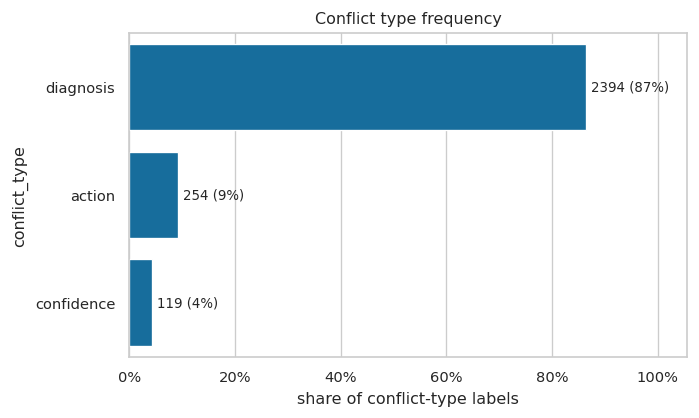

,conflict_type,count,share
0,diagnosis,2394,0.865197
1,action,254,0.091796
2,confidence,119,0.043007


In [5]:
type_counts = conflict_type_counts(run.conflicts)
if not type_counts.empty:
	type_counts["share"] = type_counts["count"] / type_counts["count"].sum()
	fig, ax = plt.subplots(figsize=(6, 3.5))
	sns.barplot(data=type_counts, x="share", y="conflict_type", ax=ax)
	ax.set_title("Conflict type frequency")
	ax.set_xlabel("share of conflict-type labels")
	ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda value, _: f"{value:.0%}"))
	annotate_count_percent_bars(ax, type_counts["count"], type_counts["share"], orientation="horizontal")
	display_saved_fig(fig, "conflict_type_frequency")
display(type_counts)


The **Conflict type frequency** chart counts the kinds of disagreements the resolver had to handle. In this run there were **2,673 conflicts**. The most common conflict type was **diagnosis disagreement** (**2,394 conflicts**), followed by **action disagreement** (**254**) and **confidence disagreement** (**119**). A single conflict can contribute to more than one category, so these counts add up to more than 2,673.

The result is that the resolver was tested overwhelmingly on choosing the right diagnosis. Action and confidence-only disagreements were far less central. This matters for the thesis because the dominant workload was not just deciding whether agents were confident; it was resolving concrete disagreement about what problem was actually present.


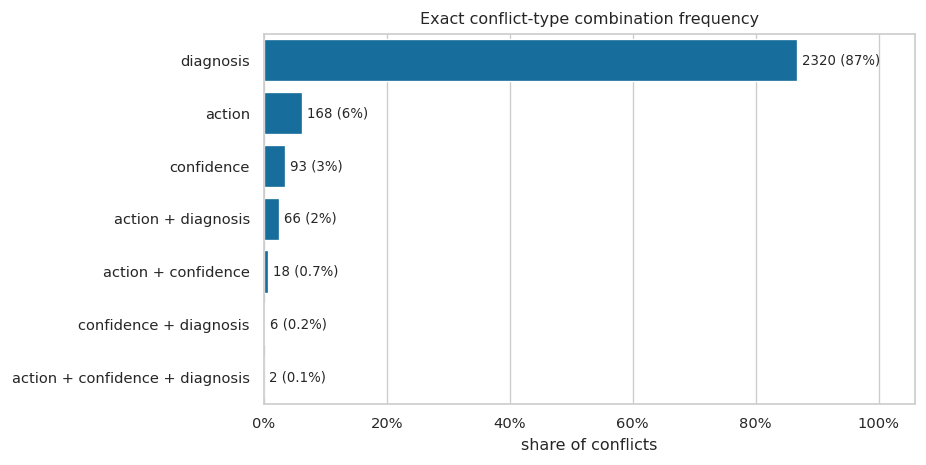

,conflict_type_combination,count,share
0,diagnosis,2320,0.867939
1,action,168,0.062851
2,confidence,93,0.034792
3,action + diagnosis,66,0.024691
4,action + confidence,18,0.006734
5,confidence + diagnosis,6,0.002245
6,action + confidence + diagnosis,2,0.000748


In [6]:
if not run.conflicts.empty and "conflict_types" in run.conflicts:
	combination_counts = (
		run.conflicts["conflict_types"]
		.dropna()
		.map(lambda values: " + ".join(sorted(values)) if isinstance(values, list) else "unknown")
		.value_counts()
		.reset_index()
	)
	combination_counts.columns = ["conflict_type_combination", "count"]
	combination_counts["share"] = combination_counts["count"] / combination_counts["count"].sum()
	fig, ax = plt.subplots(figsize=(7, 4))
	sns.barplot(data=combination_counts.head(10), x="share", y="conflict_type_combination", ax=ax)
	ax.set_title("Exact conflict-type combination frequency")
	ax.set_xlabel("share of conflicts")
	ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda value, _: f"{value:.0%}"))
	ax.set_ylabel("")
	plot_combinations = combination_counts.head(10)
	annotate_count_percent_bars(ax, plot_combinations["count"], plot_combinations["share"], orientation="horizontal")
	display_saved_fig(fig, "conflict_type_cooccurrence")
	display(combination_counts)
else:
	display(pd.DataFrame())


The **Exact conflict-type combination frequency** chart shows which conflict types occurred together in the same resolver decision. The dominant case was a **diagnosis-only conflict** with **2,320 conflicts**. The next largest groups were **action only** (**168**), **confidence only** (**93**), and **action + diagnosis** (**66**), with smaller tails of **action + confidence** (**18**), **confidence + diagnosis** (**6**), and **action + confidence + diagnosis** (**2**).

The result is that the vast majority of conflicts were focused: they involved diagnosis disagreement without simultaneous action or confidence disagreement. Only a small minority combined diagnosis and action disagreement, which is harder because the resolver had to choose both the right explanation and the right intervention. The chart therefore shows that the evaluation is dominated by simple diagnosis conflicts plus a much smaller set of multi-part conflicts.


## 3. Sub-question 2: Does the chosen monitoring-agent output format support consistent conflict detection and traceability to evidence and ground truth?


This section verifies whether the chosen structured output format supports the analysis task. The format is effective when conflicts, decisions, and actions carry identifiers that can be resolved back to generated monitoring reports and compared with ground truth.

Traceability checks whether those links are intact. Evaluability checks whether a ground-truth fault had enough observable evidence to score it fairly. All ground-truth rows are evaluable for decision scoring. Derived issues are attributed through decisions because they have no standalone sensor signal.


In [7]:
traceability = traceability_audit(run)
display(traceability)


,measure,value,numerator,denominator
0,conflict_report_ids_resolve,1.0,5393,5393
1,decision_support_ids_resolve,1.0,5393,5393
2,agent_action_report_ids_resolve,1.0,1639,1639
3,runtime_report_id_uniqueness,1.0,20198,20198
4,decision_to_conflict_match_rate,1.0,2673,2673


In [8]:
ground_truth_audit = ground_truth_audit_table(run)
duplicate_diagnoses = duplicate_ground_truth_diagnosis_audit(run)
display(ground_truth_audit)
if duplicate_diagnoses.empty:
	display(Markdown("No duplicate ground-truth diagnoses were found. This is a useful validity check: each diagnosis identifier maps to a single expected repair target, so per-fault recall and action-selection rates are not inflated or made ambiguous by repeated answer-key rows."))
else:
	display(Markdown("Duplicate ground-truth diagnoses were found. These rows need inspection because repeated diagnosis identifiers can make per-fault scoring ambiguous."))
	display(duplicate_diagnoses)
if "diagnosis" in run.ground_truth:
	root_types = run.ground_truth["diagnosis"].dropna().astype(str).str.split(":").str[-1].value_counts().reset_index()
	root_types.columns = ["fault_type", "count"]
	display(root_types)


,measure,value
0,all_faults,130
1,root_faults,77
2,derived_issues,35
3,physical_state_issues,18
4,detection_evaluable_faults,95
5,evaluation_role:root_fault,77
6,evaluation_role:derived_issue_context,35
7,evaluation_role:physical_state_response,18
8,evaluable_rows,130
9,duplicate_diagnosis_groups,0


No duplicate ground-truth diagnoses were found. This is a useful validity check: each diagnosis identifier maps to a single expected repair target, so per-fault recall and action-selection rates are not inflated or made ambiguous by repeated answer-key rows.

,fault_type,count
0,no_signal,21
1,stuck,20
2,belt_slippage,7
3,overheating,7
4,handoff_blocked,7
5,production_blocked,7
6,production_slowdown,7
7,transfer_rate_degraded,7
8,low_battery,7
9,persistent_queue_pressure,7


In [9]:
first_fault = run.ground_truth.iloc[0].to_dict() if not run.ground_truth.empty else {}
first_diagnosis = first_fault.get("diagnosis")
trace_rows = [{"stage": "ground truth", "id": first_fault.get("root_fault"), "detail": first_fault.get("required_action")}]
if first_diagnosis and not run.runtime_reports.empty:
	matching_reports = run.runtime_reports[run.runtime_reports.get("diagnosis_id") == first_diagnosis].head(3)
	for row in matching_reports.to_dict("records"):
		trace_rows.append({"stage": "report", "id": row.get("report_id"), "detail": row.get("recommended_action")})
if first_diagnosis and not run.conflicts.empty:
	for row in run.conflicts[run.conflicts.get("diagnoses", pd.Series(dtype=object)).map(lambda xs: first_diagnosis in xs if isinstance(xs, list) else False)].head(2).to_dict("records"):
		trace_rows.append({"stage": "conflict", "id": row.get("conflict_id"), "detail": row.get("conflict_types")})
trace = pd.DataFrame(trace_rows)
display(trace)


,stage,id,detail
0,ground truth,belt:Final-Inspection:FinalStorage:belt_slippage,fix_belt_slippage
1,report,BeltSegment@Final-Inspection->FinalStorage-Fin...,fix_belt_slippage
2,report,BeltSegment@Final-Inspection->FinalStorage-Fin...,fix_belt_slippage
3,report,BeltSegment@Final-Inspection->FinalStorage-Fin...,fix_belt_slippage


## 4. Sub-question 3: How accurately does the LLM conflict resolver select the ground-truth diagnosis and action in the fixed production run?


This section reports at-least-once per-fault outcome/recall metrics separately from per-decision resolver accuracy by conflict type.


In [10]:
per_fault_metrics = pd.DataFrame([
	{"metric": key, "value": value}
	for key, value in run.per_fault_metrics.items()
	if "latency" not in str(key).lower()
])
detection_metrics = pd.DataFrame([
	{"metric": key, "value": value}
	for key, value in run.detection_metrics.items()
])
display(per_fault_metrics)
display(detection_metrics)

display(Markdown("`evaluable_faults` is lower than `all_faults` because detection scoring excludes `derived_issue` rows. Derived issues have no standalone injected fault signal; they are evaluated through resolver attribution and cascade scoring instead. The ground-truth audit above reports both all rows and detection-evaluable rows."))


,metric,value
0,action_attempt_success_rate,0.97925
1,diagnosis_precision,1.00000
2,evaluable_faults,95.00000
3,fault_action_execution_rate,1.00000
4,per_fault_action_selected_rate,1.00000
5,per_fault_diagnosis_recall,1.00000
6,physical_state_faults,18.00000
7,physical_state_per_fault_action_selected_rate,1.00000
8,physical_state_per_fault_diagnosis_recall,1.00000
9,required_action_execution_rate,1.00000


,metric,value
0,diagnosis_precision,1.000000
1,evaluable_faults,95.000000
2,mean_detection_latency,1.633598
3,median_detection_latency,0.390511


`evaluable_faults` is lower than `all_faults` because detection scoring excludes `derived_issue` rows. Derived issues have no standalone injected fault signal; they are evaluated through resolver attribution and cascade scoring instead. The ground-truth audit above reports both all rows and detection-evaluable rows.

,source,metric,rate,faults
0,all,diagnosis_correct_rate,1.0,95
1,all,action_selected_rate,1.0,95
2,all,action_correct_rate,1.0,95
3,all,action_executed_rate,1.0,95
4,physical_state,diagnosis_correct_rate,1.0,18
5,physical_state,action_selected_rate,1.0,18
6,physical_state,action_correct_rate,1.0,18
7,physical_state,action_executed_rate,1.0,18
8,root_fault,diagnosis_correct_rate,1.0,77
9,root_fault,action_selected_rate,1.0,77


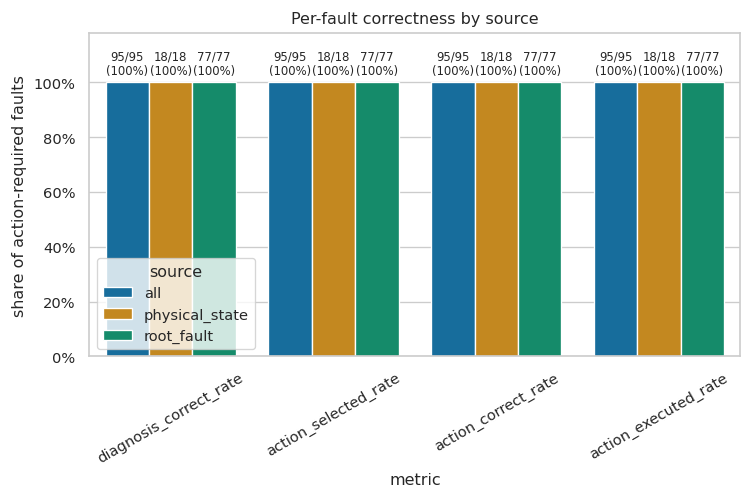

In [11]:
per_fault = run.per_fault.copy()
if not per_fault.empty:
	if "source" not in per_fault:
		per_fault["source"] = "root_fault"
	rate_specs = [
		("diagnosis_correct", "diagnosis_correct_rate"),
		("action_selected", "action_selected_rate"),
		("action_correct", "action_correct_rate"),
		("action_executed", "action_executed_rate"),
	]
	rate_rows = []
	for source_label, group in [("all", per_fault), *per_fault.groupby("source", dropna=False)]:
		for column, metric in rate_specs:
			if column in group:
				rate_rows.append({"source": source_label, "metric": metric, "rate": group[column].fillna(False).mean(), "faults": len(group)})
	rate_table = pd.DataFrame(rate_rows)
	display(rate_table)
	
	if not rate_table.empty:
		fig, ax = plt.subplots(figsize=(7, 3.5))
		sns.barplot(data=rate_table, x="metric", y="rate", hue="source", ax=ax)
		ax.set_ylim(0, 1)
		ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda value, _: f"{value:.0%}"))
		ax.set_ylabel("share of action-required faults")
		ax.set_title("Per-fault correctness by source")
		ax.tick_params(axis="x", rotation=30)
		annotate_grouped_rate_bars(ax, rate_table, x="metric", hue="source", value="rate", denominator="faults")
		display_saved_fig(fig, "per_fault_correctness_by_source")
else:
	print("No per-fault correctness rows available.")


The **Per-fault correctness by source** chart checks how well the system eventually handled each evaluable ground-truth fault. A **fault** means one known problem in the answer key. Ground truth says what really happened and what repair action should fix it. This chart uses **95 evaluable faults**: **77 root faults** and **18 physical-state faults**.

The visible result is perfect at the per-fault level. The system diagnosed **95/95 faults correctly** (**100%**), and it also selected, matched, and executed the correct repair action on **95/95 faults** (**100%**). Both groups are clean: root faults are **77/77** and physical-state faults are **18/18** on all four metrics.

This means the system reached the right final outcome for every fault, even though some individual resolver decisions were weaker elsewhere in the notebook. The practical interpretation is: over the full run, faults were eventually recognized and repaired with complete reliability, and the per-decision weaknesses shown later did not leave any fault unresolved.


,action_accuracy,decisions,diagnosis_accuracy,conflict_type
0,0.258885,2673,0.643846,overall


,conflict_type,action_accuracy,decisions,diagnosis_accuracy
0,action,0.854331,254,0.944882
1,confidence,0.478992,119,0.781513
2,diagnosis,0.199248,2394,0.613200


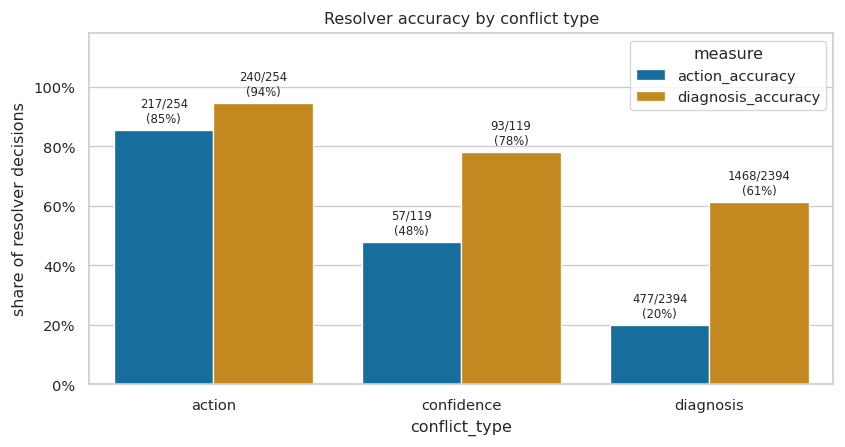

In [12]:
resolution_rows = []
for conflict_type, values in (run.resolution_correctness.get("by_conflict_type") or {}).items():
	row = {"conflict_type": conflict_type, **values}
	resolution_rows.append(row)
resolution_by_type = pd.DataFrame(resolution_rows)
overall_resolution = pd.DataFrame([{**(run.resolution_correctness.get("overall") or {}), "conflict_type": "overall"}])
display(overall_resolution)
display(resolution_by_type)
if not resolution_by_type.empty:
	plot_rows = resolution_by_type.melt(
		id_vars=["conflict_type", "decisions"],
		var_name="measure",
		value_name="accuracy",
	).dropna(subset=["accuracy"])
	fig, ax = plt.subplots(figsize=(8, 3.8))
	sns.barplot(data=plot_rows, x="conflict_type", y="accuracy", hue="measure", ax=ax)
	ax.set_ylim(0, 1)
	ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda value, _: f"{value:.0%}"))
	ax.set_ylabel("share of resolver decisions")
	ax.set_title("Resolver accuracy by conflict type")
	annotate_grouped_rate_bars(ax, plot_rows, x="conflict_type", hue="measure", value="accuracy", denominator="decisions")
	display_saved_fig(fig, "resolution_accuracy_by_conflict_type")


The **Resolver accuracy by conflict type** chart evaluates each individual LLM resolver decision. This is stricter than the per-fault chart because it asks whether the resolver made the correct choice at that specific decision point, not whether the fault was eventually handled later.

The visible result is much weaker than the per-fault outcome. Across **2,673 resolver decisions**, diagnosis accuracy is **64.4%**, but action accuracy is only **25.9%**. The resolver performs best when the conflict includes action disagreement: **94.5% diagnosis accuracy** and **85.4% action accuracy** for the **254** action conflicts. It performs worst on the dominant **diagnosis conflicts** (**2,394** decisions): **61.3% diagnosis accuracy** and only **19.9% action accuracy**. Confidence conflicts (**119** decisions) sit between those, with **78.2% diagnosis accuracy** and **47.9% action accuracy**.

The main interpretation is that the system can still eventually fix every fault, but the resolver is not consistently making the ideal decision at each conflict. The biggest weakness is action choice during diagnosis-conflict situations, where most decisions select a passive or otherwise non-ground-truth action even though the later workflow recovers. Because diagnosis-only conflicts make up the large majority of decisions, their low action accuracy dominates the headline 25.9% figure.


In [13]:
decision_failure_modes = decision_failure_taxonomy(run.resolution_per_decision)
display(decision_failure_modes)


,failure_mode,decisions,share
2,passive_without_root_handling,1981,0.741115
1,passive_after_root_handled,367,0.137299
0,active_action_correct,325,0.121586


### Resolver confidence calibration


,decision_source,confidence,decisions,diagnosis_accuracy,action_accuracy,passive_share
0,model,high,2668,0.643178,0.258246,0.878936
2,model,medium,3,1.000000,0.333333,1.000000
1,model,low,1,1.000000,1.000000,0.000000
3,model,very_high,1,1.000000,1.000000,0.000000


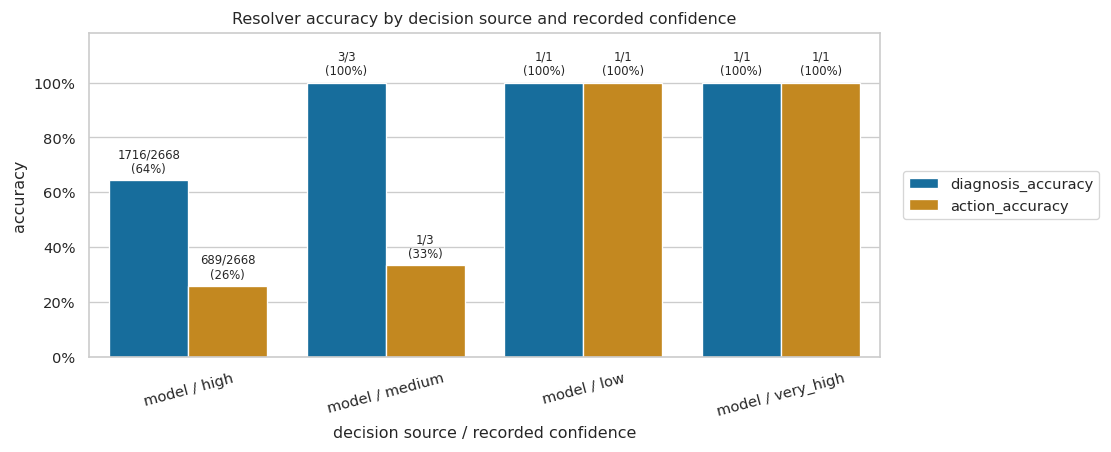

In [14]:
confidence_decisions = pd.json_normalize(run.raw["resolver_correctness"]["per_decision"])

# decision_source separates a genuine model self-assessment from the parser
# fallback (which stamps confidence="low" + wait_for_more_evidence on a parse
# failure). Prefer the scored field; for older runs that predate it, derive it
# from the decision metadata (metadata.fell_back) joined on decision_id.
if "decision_source" not in confidence_decisions.columns:
	llm_decisions = pd.json_normalize(run.raw.get("runtime_llm_decisions", []))
	fell_back_by_id = {}
	if not llm_decisions.empty and "decision_id" in llm_decisions:
		fell_back_col = "metadata.fell_back"
		for _, row in llm_decisions.iterrows():
			fell_back_by_id[row["decision_id"]] = bool(row.get(fell_back_col)) if fell_back_col in llm_decisions else False
	confidence_decisions["decision_source"] = confidence_decisions["decision_id"].map(
		lambda decision_id: "fallback" if fell_back_by_id.get(decision_id) else "model"
	)

if "confidence" in confidence_decisions:
	confidence_calibration = (
		confidence_decisions.groupby(["decision_source", "confidence"])
		.agg(
			decisions=("confidence", "size"),
			diagnosis_accuracy=("diagnosis_correct", "mean"),
			action_accuracy=("action_correct", "mean"),
			passive_share=("selected_action", lambda actions: actions.eq("wait_for_more_evidence").mean()),
		)
		.reset_index()
		.sort_values("decisions", ascending=False)
	)
	display(confidence_calibration)
	confidence_calibration["group"] = confidence_calibration["decision_source"] + " / " + confidence_calibration["confidence"]
	calibration_plot = confidence_calibration.melt(
		id_vars=["group", "decision_source", "confidence", "decisions"],
		value_vars=["diagnosis_accuracy", "action_accuracy"],
		var_name="measure",
		value_name="accuracy",
	)
	fig, ax = plt.subplots(figsize=(8.5, 3.5))
	sns.barplot(data=calibration_plot, x="group", y="accuracy", hue="measure", ax=ax)
	ax.set_ylim(0, 1)
	ax.set_title("Resolver accuracy by decision source and recorded confidence")
	ax.set_xlabel("decision source / recorded confidence")
	ax.set_ylabel("accuracy")
	ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda value, _: f"{value:.0%}"))
	ax.tick_params(axis="x", rotation=15)
	annotate_grouped_rate_bars(ax, calibration_plot, x="group", hue="measure", value="accuracy", denominator="decisions")
	ax.legend(loc="center left", bbox_to_anchor=(1.02, 0.5))
	display_saved_fig(fig, "resolver_confidence_calibration")


The **Resolver accuracy by decision source and recorded confidence** chart breaks the resolver decisions down two ways at once: by `decision_source` (`model` vs `fallback`) and by the recorded `confidence` value. The `decision_source` field separates a genuine model self-assessment from the parser fallback, which stamps `confidence="low"` + `wait_for_more_evidence` whenever no valid decision could be parsed after all retries.

In this run there were **no parser fallbacks at all**: every one of the **2,673** decisions has `decision_source="model"`, so the model produced a valid, schema-conformant decision each time. The recorded confidence is also almost entirely uniform — **2,668** decisions are `high`, with only a negligible tail of `medium` (**3**), `very_high` (**1**), and `low` (**1**). The single `low` decision came from the model itself, not a parse failure.

Because the recorded confidence is almost uniformly `high`, this run cannot meaningfully evaluate confidence calibration; the action-accuracy story lives elsewhere. Within the dominant `model / high` bucket, **87.9%** of decisions are the passive `wait_for_more_evidence`, and that high deferral share — not reckless misfiring — is what drives the low headline per-decision action accuracy. When the resolver instead commits to an active repair it is reliably correct; deferred conditions keep being re-reported until a later active decision resolves them, which is consistent with the perfect eventual per-fault repair rate.


### Worked decision examples



In [15]:
decision_examples = example_decisions(run)
display(decision_examples)

if not decision_examples.empty:
	example = decision_examples.iloc[0]
	display(Markdown(
		f"Example `{example['decision_id']}` came from conflict `{example['conflict_id']}` "
		f"({example['conflict_types']}). The resolver selected "
		f"`{example['selected_diagnosis_id']}` with action `{example['selected_action']}` "
		f"It is scored as `{example['failure_mode']}` because that is the taxonomy label "
		f"derived from the scorer-provided correctness and attribution fields."
	))


,failure_mode,decision_id,conflict_id,conflict_types,conflict_window,selected_diagnosis_id,selected_action,expected_action,matched_truth_source,derived_issue_attribution_status
0,active_action_correct,resolution-conflict-Body-Welding-Cell-t48-1,conflict-Body-Welding-Cell-t48-1,"[diagnosis, action]","{'start': 48.0, 'end': 52.0}",temperature:Body-Welding-Cell:overheating,start_cooling,start_cooling,physical_state,not_derived_issue
1,passive_after_root_handled,resolution-conflict-line-t364-1,conflict-line-t364-1,[diagnosis],"{'start': 364.0, 'end': 368.0}",belt:Body-Welding-Cell:Paint-Booth:persistent_...,wait_for_more_evidence,fix_belt_jam,derived_issue,attributed_to_root
2,passive_without_root_handling,resolution-conflict-line-t476-1,conflict-line-t476-1,[diagnosis],"{'start': 476.0, 'end': 480.0}",machine:Sheet-Metal-Press:production_blocked,wait_for_more_evidence,,derived_issue,no_root_cause_found


Example `resolution-conflict-Body-Welding-Cell-t48-1` came from conflict `conflict-Body-Welding-Cell-t48-1` (['diagnosis', 'action']). The resolver selected `temperature:Body-Welding-Cell:overheating` with action `start_cooling` It is scored as `active_action_correct` because that is the taxonomy label derived from the scorer-provided correctness and attribution fields.

## 5. Sub-question 4: Which failure modes occur across monitoring, conflict detection, LLM resolution, and action execution when resolver outputs are compared with ground truth?


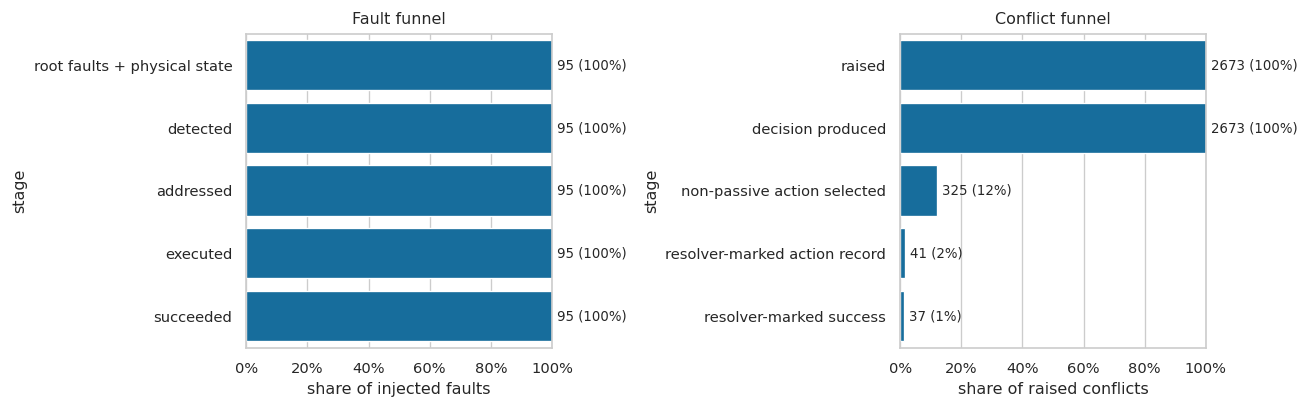

,stage,count,share
0,root faults + physical state,95,1.0
1,detected,95,1.0
2,addressed,95,1.0
3,executed,95,1.0
4,succeeded,95,1.0


,stage,count,share
0,raised,2673,1.000000
1,decision produced,2673,1.000000
2,non-passive action selected,325,0.121586
3,resolver-marked action record,41,0.015339
4,resolver-marked success,37,0.013842


In [16]:
def _truth_count(column: str) -> int:
	return int(run.per_fault.get(column, pd.Series(dtype=bool)).fillna(False).sum()) if column in run.per_fault else 0

injected_fault_sources = {"root_fault", "physical_state"}
injected_faults = 0
if not run.per_fault.empty:
	per_fault_sources = run.per_fault.get("source", pd.Series("root_fault", index=run.per_fault.index)).fillna("root_fault")
	injected_faults = int(per_fault_sources.isin(injected_fault_sources).sum())

succeeded_faults = _truth_count("action_executed")

fault_funnel = pd.DataFrame([
	{"stage": "root faults + physical state", "count": injected_faults},
	{"stage": "detected", "count": _truth_count("detected")},
	{"stage": "addressed", "count": _truth_count("action_correct")},
	{"stage": "executed", "count": _truth_count("action_executed")},
	{"stage": "succeeded", "count": succeeded_faults},
])

resolver_action_records = run.agent_actions.copy()
if not resolver_action_records.empty:
	resolver_action_records = resolver_action_records[resolver_action_records.get("selected_by_resolver", pd.Series(False, index=resolver_action_records.index)).fillna(False)]
resolver_success_records = resolver_action_records.copy()
if not resolver_success_records.empty:
	resolver_success_records = resolver_success_records[resolver_success_records.get("execution_succeeded", pd.Series(False, index=resolver_success_records.index)).fillna(False)]

conflict_decisions = run.decisions.copy()
if not conflict_decisions.empty and "conflict_id" in conflict_decisions:
	conflict_decisions = conflict_decisions.dropna(subset=["conflict_id"])
else:
	conflict_decisions = pd.DataFrame()
non_passive_decisions = conflict_decisions.copy()
if not non_passive_decisions.empty and "selected_action" in non_passive_decisions:
	non_passive_decisions = non_passive_decisions[~non_passive_decisions["selected_action"].isin(PASSIVE_ACTIONS)]
else:
	non_passive_decisions = pd.DataFrame()
conflict_funnel = pd.DataFrame([
	{"stage": "raised", "count": len(run.conflicts)},
	{"stage": "decision produced", "count": conflict_decisions["conflict_id"].nunique() if "conflict_id" in conflict_decisions else 0},
	{"stage": "non-passive action selected", "count": non_passive_decisions["conflict_id"].nunique() if "conflict_id" in non_passive_decisions else 0},
	{"stage": "resolver-marked action record", "count": len(resolver_action_records)},
	{"stage": "resolver-marked success", "count": len(resolver_success_records)},
])

fault_funnel["share"] = fault_funnel["count"] / fault_funnel["count"].iloc[0] if fault_funnel["count"].iloc[0] else 0
conflict_funnel["share"] = conflict_funnel["count"] / conflict_funnel["count"].iloc[0] if conflict_funnel["count"].iloc[0] else 0
fig, axes = plt.subplots(1, 2, figsize=(11, 3.5))
sns.barplot(data=fault_funnel, x="share", y="stage", ax=axes[0])
axes[0].set_title("Fault funnel")
axes[0].set_xlabel("share of injected faults")
axes[0].set_xlim(0, 1)
axes[0].xaxis.set_major_formatter(plt.FuncFormatter(lambda value, _: f"{value:.0%}"))
annotate_count_percent_bars(axes[0], fault_funnel["count"], fault_funnel["share"], orientation="horizontal")
sns.barplot(data=conflict_funnel, x="share", y="stage", ax=axes[1])
axes[1].set_title("Conflict funnel")
axes[1].set_xlabel("share of raised conflicts")
axes[1].set_xlim(0, 1)
axes[1].xaxis.set_major_formatter(plt.FuncFormatter(lambda value, _: f"{value:.0%}"))
annotate_count_percent_bars(axes[1], conflict_funnel["count"], conflict_funnel["share"], orientation="horizontal")
fig.tight_layout()
display_saved_fig(fig, "outcome_funnels")
display(fault_funnel)
display(conflict_funnel)


The **Fault funnel** and **Conflict funnel** charts show how many items remain at each step of the workflow. The Fault funnel starts from known ground-truth problems; the Conflict funnel starts from disagreements between agents.

The Fault funnel shows a perfect end-to-end result: the run contains **95 faults** that require an action (**77 root faults** plus **18 physical-state faults**). All **95** faults were detected, all **95** were addressed with the correct action, all **95** had that action executed, and all **95** succeeded. There is no drop anywhere in the funnel, matching the 100% per-fault correctness seen earlier.

The Conflict funnel shows the resolver workload and where many decisions become passive. There were **2,673 conflicts** and **2,673 decisions**, so every conflict received a decision. Only **325 conflicts** led to a non-passive selected action, and selected resolver actions are not the same denominator as execution records: recurring selected reports are suppressed once a matching action is active. The run has **41** resolver-marked action records, with **37** successes, **3** already-resolved outcomes, and **1** failure. This means the conflict-level bottleneck is still the earlier resolver behavior where the great majority of decisions choose `wait_for_more_evidence`, while eventual recovery also depends on direct and supplemental repair paths.


,execution_outcome,count
0,succeeded,1463
1,already_resolved,145
2,failed,31


,failure_reason,count
0,None,1608
1,execution_failed,31


,fault_type,count,mean,median,max
0,actuator:slow_response,7,1.285714,1.0,2
1,actuator:stuck,6,1.500000,1.5,2
2,belt:belt_jam,6,1.166667,1.0,2
3,belt:belt_slippage,7,1.142857,1.0,2
4,machine:bearing_wear,7,1.714286,2.0,2
5,machine:jammed_workpiece,7,1.714286,2.0,2
6,network:latency,1,4.000000,4.0,4
7,network:packet_loss,1,2.000000,2.0,2
8,sensor:ActuatorSensor:no_signal,7,1.428571,1.0,2
9,sensor:Power:no_signal,7,1.428571,1.0,2


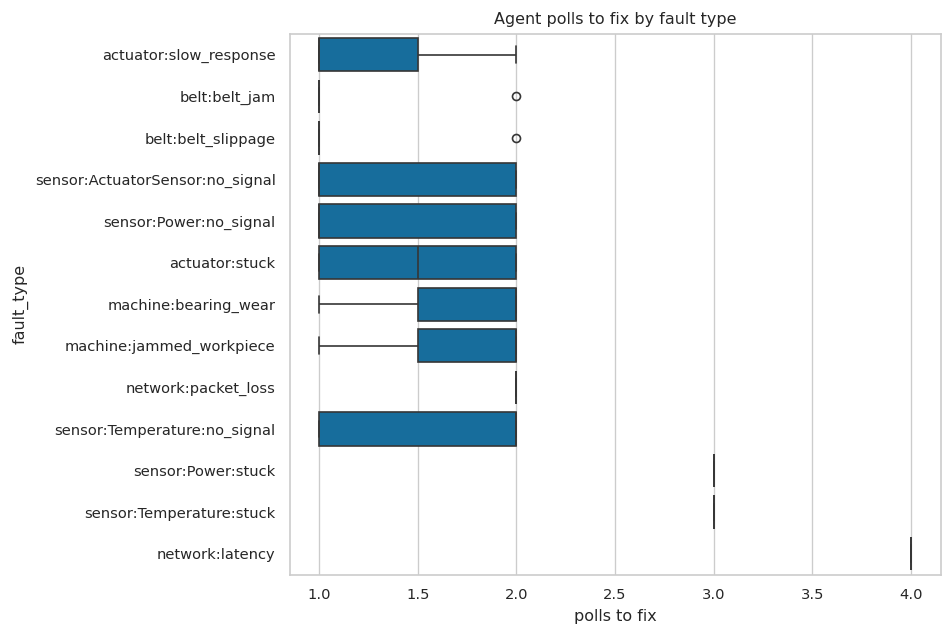

,selected_action,count,share,passive
0,wait_for_more_evidence,2348,0.878414,True
1,start_cooling,275,0.102881,False
2,start_intense_cooling,21,0.007856,False
3,fix_stuck,9,0.003367,False
4,fix_slow_response,5,0.001871,False
5,fix_jammed_workpiece,5,0.001871,False
6,fix_belt_jam,3,0.001122,False
7,fix_packet_loss,2,0.000748,False
8,fix_no_signal,2,0.000748,False
9,replace_battery,1,0.000374,False


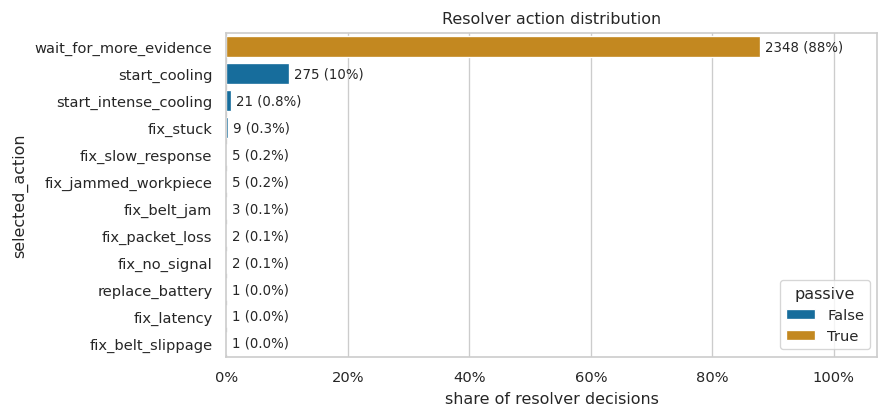

In [17]:
def _fault_type(diagnosis: object) -> str:
	if not isinstance(diagnosis, str):
		return "unknown"
	parts = diagnosis.split(":")
	if parts[0] == "sensor" and len(parts) >= 4:
		# keep the sensor subsystem so e.g. Power vs Temperature sensors stay distinct
		return f"sensor:{parts[-2]}:{parts[-1]}"
	return f"{parts[0]}:{parts[-1]}" if len(parts) > 1 else diagnosis

if not run.agent_actions.empty:
	display(run.agent_actions.get("execution_outcome", pd.Series(dtype=object)).value_counts(dropna=False).reset_index(name="count"))
	display(run.agent_actions.get("failure_reason", pd.Series(dtype=object)).value_counts(dropna=False).reset_index(name="count"))


# Agent polls required to fix each fault type, from the cascade resolution (fault_resolved event).
polls_by_fault_type = run.cascade_per_fault.copy()
if not polls_by_fault_type.empty and {"root_fault", "polls_to_resolution"}.issubset(polls_by_fault_type.columns):
	polls_by_fault_type = polls_by_fault_type.dropna(subset=["polls_to_resolution"]).copy()
	if not polls_by_fault_type.empty:
		polls_by_fault_type["fault_type"] = polls_by_fault_type["root_fault"].map(_fault_type)
		polls_summary = polls_by_fault_type.groupby("fault_type")["polls_to_resolution"].agg(["count", "mean", "median", "max"]).reset_index()
		display(polls_summary)
		fault_type_order = polls_by_fault_type.groupby("fault_type")["polls_to_resolution"].median().sort_values().index.tolist()
		fig, ax = plt.subplots(figsize=(7, max(3.5, 0.45 * len(fault_type_order))))
		sns.boxplot(data=polls_by_fault_type, x="polls_to_resolution", y="fault_type", order=fault_type_order, ax=ax)
		ax.set_title("Agent polls to fix by fault type")
		ax.set_xlabel("polls to fix")
		display_saved_fig(fig, "polls_to_fix_by_fault_type")

if not run.decisions.empty and "selected_action" in run.decisions:
	action_distribution = run.decisions["selected_action"].value_counts(dropna=False).reset_index(name="count")
	action_distribution.columns = ["selected_action", "count"]

	action_distribution["share"] = action_distribution["count"] / action_distribution["count"].sum()
	action_distribution["passive"] = action_distribution["selected_action"].isin(PASSIVE_ACTIONS)
	display(action_distribution)
	fig, ax = plt.subplots(figsize=(7, 3.5))
	sns.barplot(data=action_distribution.head(12), x="share", y="selected_action", hue="passive", dodge=False, ax=ax)
	ax.set_title("Resolver action distribution")
	ax.set_xlabel("share of resolver decisions")
	ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda value, _: f"{value:.0%}"))
	annotate_horizontal_percent_patches(ax, int(action_distribution["count"].sum()))
	display_saved_fig(fig, "resolver_action_distribution")

The **Agent polls to fix by fault type** chart shows how many repeated system checks were needed before each fault type was resolved. Lower values mean faster resolution. Belt faults were among the quickest: both `belt:belt_jam` and `belt:belt_slippage` had a median of **1 poll** (max **2**). Most actuator, machine, and sensor faults also centered tightly around **1-2 polls**.

The slower cases are visible at the high end, but the spread is narrow. `sensor:Power:stuck` and `sensor:Temperature:stuck` each had a median of **3 polls** (max **3**), and the single `network:latency` case took **4 polls** — the slowest fault type in the run. This means every fault type was fixed within a few cycles, with no long unresolved tail.

The **Resolver action distribution** chart explains the resolver-accuracy gap. The most common selected action by a wide margin was `wait_for_more_evidence` with **2,348 decisions**, far outnumbering all active repair choices combined. The largest active actions were `start_cooling` (**275**) and `start_intense_cooling` (**21**), followed by small counts of `fix_stuck` (**9**), `fix_slow_response` (**5**), and `fix_jammed_workpiece` (**5**). The result is that the resolver overwhelmingly chose a passive action, which is exactly why per-decision action accuracy is so much lower than the eventual per-fault repair success.


,metric,value
0,root_faults,77.0
1,n_contained,39.0
2,n_cascaded,38.0
3,n_containable,39.0
4,n_structurally_cascading,38.0
5,n_contained_given_containable,39.0
6,contained_rate_over_containable,1.0


,metric,value
3,n_containable,39.0
4,n_structurally_cascading,38.0
5,n_contained_given_containable,39.0
6,contained_rate_over_containable,1.0


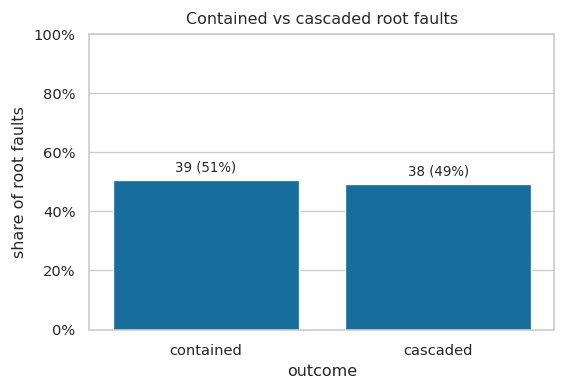

In [18]:
cascade_metrics = pd.DataFrame([{"metric": key, "value": value} for key, value in (run.cascade.get("metrics") or {}).items()])
display(cascade_metrics)
cascade_faults = run.cascade_per_fault.copy()
if not cascade_faults.empty:
	resolver_quality_metrics = ["n_containable", "n_structurally_cascading", "n_contained_given_containable", "contained_rate_over_containable"]
	available_resolver_metrics = cascade_metrics[cascade_metrics["metric"].isin(resolver_quality_metrics)] if not cascade_metrics.empty else pd.DataFrame()
	if not available_resolver_metrics.empty:
		display(available_resolver_metrics)

	contained_counts = cascade_faults["contained"].map({True: "contained", False: "cascaded"}).value_counts().reset_index() if "contained" in cascade_faults else pd.DataFrame()
	if not contained_counts.empty:
		contained_counts.columns = ["outcome", "count"]
		contained_counts["share"] = contained_counts["count"] / contained_counts["count"].sum()
		fig, ax = plt.subplots(figsize=(5, 3.2))
		sns.barplot(data=contained_counts, x="outcome", y="share", ax=ax)
		ax.set_title("Contained vs cascaded root faults")
		ax.set_ylabel("share of root faults")
		ax.set_ylim(0, 1)
		ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda value, _: f"{value:.0%}"))
		annotate_count_percent_bars(ax, contained_counts["count"], contained_counts["share"])
		display_saved_fig(fig, "contained_vs_cascaded")
else:
	print("No cascade rows available.")


The **Contained vs cascaded root faults** chart separates the **77 root faults** into outcomes. **39 root faults** were contained, while **38 cascaded** into downstream effects. All **39 containable** root faults were contained, giving a containable-conditioned containment rate of **100%**.

The visible result is strong. Every fault that had at least one polling-cycle opportunity to be contained was contained. The remaining **38** cascaded because their first downstream effect appeared before the next 4-time-unit monitoring poll could react. Containment slightly outnumbers cascades in this run (**39 vs 38**), while the containable-under-this-polling-setup subset is fully contained.

The cascade scoring for this run records containment, depth, and timing per root fault but does not assign a per-fault severity label, so no cascade-severity chart is produced. The containment counts above are therefore the evidence for cascade behavior in this notebook.


,cascade_depth,root_faults,share
0,0,39,0.506494
1,1,32,0.415584
2,2,3,0.038961
3,3,3,0.038961


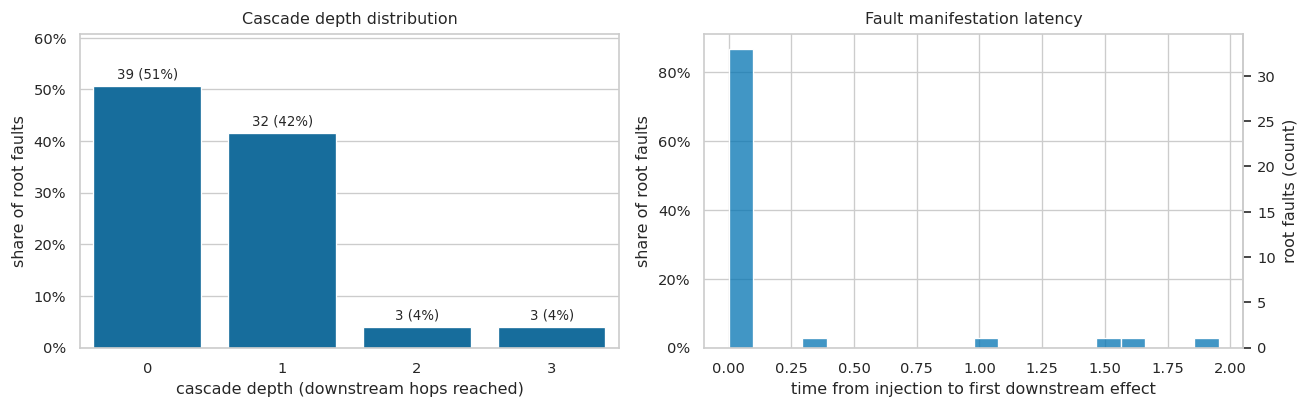

In [19]:
cascade_structure = run.cascade_per_fault.copy()
if not cascade_structure.empty and {"depth", "manifestation_latency"}.issubset(cascade_structure.columns):
	depth_distribution = cascade_structure["depth"].value_counts().sort_index().reset_index()
	depth_distribution.columns = ["cascade_depth", "root_faults"]
	depth_distribution["share"] = depth_distribution["root_faults"] / depth_distribution["root_faults"].sum()
	display(depth_distribution)
	fig, axes = plt.subplots(1, 2, figsize=(11, 3.5))
	sns.barplot(data=depth_distribution, x="cascade_depth", y="share", ax=axes[0])
	axes[0].set_title("Cascade depth distribution")
	axes[0].set_xlabel("cascade depth (downstream hops reached)")
	axes[0].set_ylabel("share of root faults")
	axes[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda value, _: f"{value:.0%}"))
	annotate_count_percent_bars(axes[0], depth_distribution["root_faults"], depth_distribution["share"])
	sns.histplot(data=cascade_structure, x="manifestation_latency", bins=20, stat="percent", ax=axes[1])
	axes[1].set_title("Fault manifestation latency")
	axes[1].set_xlabel("time from injection to first downstream effect")
	axes[1].set_ylabel("share of root faults")
	axes[1].yaxis.set_major_formatter(plt.FuncFormatter(lambda value, _: f"{value:.0f}%"))
	latency_count = cascade_structure["manifestation_latency"].notna().sum()
	if latency_count:
		count_axis = axes[1].secondary_yaxis("right", functions=(lambda percent: percent * latency_count / 100, lambda count: count * 100 / latency_count))
		count_axis.set_ylabel("root faults (count)")
	fig.tight_layout()
	display_saved_fig(fig, "cascade_depth_and_manifestation")


The **Cascade depth distribution** and **Fault manifestation latency** charts characterize *how* root faults spread, complementing the contained-vs-cascaded split above.

Cascade depth counts how many downstream hops a root fault's effects reached. Most faults stayed shallow: **39 reached depth 0** — no downstream effect, and these are exactly the 39 contained faults — **32 reached depth 1**, and **3 reached depth 2**. Only **3** propagated to depth 3, the deepest in the run (`belt:Body-Welding-Cell:Paint-Booth:belt_jam`, `actuator:Interior-Fitout:stuck`, and `machine:Wheel-And-Tire-Install:bearing_wear`). So even when faults cascaded, they rarely spread more than one hop.

Manifestation latency measures how long after injection a fault produced its first downstream effect, and it is defined only for the **38 cascading faults** (the 39 contained faults never manifested downstream). Almost all cascades appeared immediately — **33 of 38** had latency **0** — with only a small tail of delayed cases up to about **2 time units** (mean **0.17**). The practical reading is that cascades are usually shallow and near-instant, so resolver responsiveness matters most in the first moments after a fault.


In [20]:
runtime_correctness = run.raw.get("runtime_correctness", {})
display(pd.DataFrame([{"list": key, "items": runtime_correctness.get(key)} for key in ["missing_actions", "missing_action_pairs", "unexpected_actions", "unexpected_action_pairs"]]))


,list,items
0,missing_actions,[]
1,missing_action_pairs,[]
2,unexpected_actions,[wait_for_more_evidence]
3,unexpected_action_pairs,"[{'action': 'wait_for_more_evidence', 'diagnos..."


## Summary CSVs

In [21]:
production_run_summary = pd.DataFrame([summary_row])

FIGURES_DIR.mkdir(parents=True, exist_ok=True)
production_run_summary.to_csv(FIGURES_DIR / "production_run_summary.csv", index=False)
decision_failure_modes.to_csv(FIGURES_DIR / "decision_failure_taxonomy.csv", index=False)
decision_examples.to_csv(FIGURES_DIR / "example_decisions.csv", index=False)
ground_truth_audit.to_csv(FIGURES_DIR / "ground_truth_audit.csv", index=False)
traceability.to_csv(FIGURES_DIR / "traceability_audit.csv", index=False)
print(f"Wrote summary CSVs to {FIGURES_DIR}")


Wrote summary CSVs to /Users/arturmucowski/Projects/thesis/simulator/output/2026-06-26_02-48-14/figures
